# NDVI Phenology & Irrigation Analysis  
### Integrating Weather Time Series + Static Plot Features  
**Research Workflow – Single Plot Prototype**

This notebook analyzes a single vineyard block using 9 years of daily NDVI, daily weather, and plot-level terrain/soil attributes.  
We aim to:
- Decompose NDVI into seasonal/trend components  
- Detect phenological inflection points  
- Explain NDVI variation using weather + static features  
- Build SARIMAX models  
- Predict the next year's vegetation curve  


In [1]:
# 0. Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

from scipy.signal import find_peaks

# 1. Load and Inspect Data
Load:
- NDVI daily time series for a single plot  
- Daily weather data  
- Static plot features (soil, slope, aspect, elevation)

Goal: Understand structure, range, and completeness.


In [2]:
df = pd.read_pickle('../data/df.pkl')

In [3]:
features = [
    'plot_id',
    'curve_mean',
    'curve_min',
    'curve_max',
    'pro_curve_mean',
    'pro_curve_min',
    'pro_curve_max',
    'plan_curve_mean',
    'plan_curve_min',
    'plan_curve_max',
    'elev_min',
    'elev_max',
    'elev_mean',
    'elev_dev_min',
    'elev_dev_max',
    'elev_dev_mean',
    'total_relief',
    'area_m2',
    'area_ha',
    'aspect_min_cos',
    'aspect_min_sin',
    'aspect_max_cos',
    'aspect_max_sin',
    'aspect_mean_cos',
    'aspect_mean_sin',
    'slope_rad',
    'slope_grad',
    'slope_x',
    'slope_y',
    'local_relief',
    'total_relief_log',
    'sandtotal_r',
    'silttotal_r',
    'claytotal_r',
    'awc_r',
    'cec7_r',
    'om_r',
    'ph1to1h2o_r',
    'ec_r',
    'profile_depth',
    'max_depth',
    'frag3to10_r',
    'fraggt10_r',
    'dbovendry_r',
    'caco3_r'
]

In [4]:
plot_id = 3499

In [5]:
plot_features = df[features][
    (df['year'] == 2016)&
    (df['plot_id'] == plot_id)
]

In [6]:
weather = pd.read_pickle('../data/PRISM/df.pkl')



weather = (
    weather
    .groupby("date", as_index=False)
    .first()
)


weather['date'] = pd.to_datetime(weather['date'])
weather['doy'] = weather['date'].dt.dayofyear
weather['year'] = weather['date'].dt.year

weather = weather.drop(weather[weather['year'] == 2025].index)
# weather

In [7]:
ndvi = pd.read_pickle('../data/ndvi/plots/ndvi_daily_interp.pkl')

In [8]:
ndvi = ndvi[ndvi['plot_id'] == plot_id].copy()

In [9]:
weather

,date,n,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year
0,2016-01-01,1,0.0000,-0.415000,-3.15300,-5.8920,2.1920,0.4860,1,2016
1,2016-01-02,1,0.0000,-4.138000,-5.38000,-6.6220,1.1680,0.5970,2,2016
2,2016-01-03,1,0.0000,-4.943000,-6.42400,-7.9050,1.1660,0.5900,3,2016
3,2016-01-04,1,1.0160,-4.861000,-6.44800,-8.0370,0.8410,0.2900,4,2016
4,2016-01-05,1,0.0000,-2.711000,-4.31500,-5.9210,1.1300,0.2980,5,2016
...,...,...,...,...,...,...,...,...,...,...
3283,2024-12-27,1,5.5226,12.897300,8.57640,4.2555,5.3272,0.0464,362,2024
3284,2024-12-28,1,2.7350,9.500899,6.92395,4.3470,1.8989,0.0603,363,2024
3285,2024-12-29,1,6.4769,13.031700,9.00255,4.9734,4.6196,0.0594,364,2024
3286,2024-12-30,1,0.9107,9.572500,6.35390,3.1353,2.6949,0.1705,365,2024


In [10]:
df = pd.merge(
    ndvi[['index', 'ndvi_smooth_interp']], 
    weather[['date', 'ppt', 'tmax', 'tmean', 'tmin', 'vpdmax', 'vpdmin', 'doy']], 
    how = 'inner', 
    left_on = 'index', 
    right_on = 'date'
)

In [11]:
df

,index,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy
0,2016-01-01,0.316611,2016-01-01,0.0000,-0.415000,-3.15300,-5.8920,2.1920,0.4860,1
1,2016-01-02,0.316611,2016-01-02,0.0000,-4.138000,-5.38000,-6.6220,1.1680,0.5970,2
2,2016-01-03,0.316611,2016-01-03,0.0000,-4.943000,-6.42400,-7.9050,1.1660,0.5900,3
3,2016-01-04,0.316611,2016-01-04,1.0160,-4.861000,-6.44800,-8.0370,0.8410,0.2900,4
4,2016-01-05,0.316611,2016-01-05,0.0000,-2.711000,-4.31500,-5.9210,1.1300,0.2980,5
...,...,...,...,...,...,...,...,...,...,...
3283,2024-12-27,0.473407,2024-12-27,5.5226,12.897300,8.57640,4.2555,5.3272,0.0464,362
3284,2024-12-28,0.473407,2024-12-28,2.7350,9.500899,6.92395,4.3470,1.8989,0.0603,363
3285,2024-12-29,0.473407,2024-12-29,6.4769,13.031700,9.00255,4.9734,4.6196,0.0594,364
3286,2024-12-30,0.473407,2024-12-30,0.9107,9.572500,6.35390,3.1353,2.6949,0.1705,365


In [12]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week

In [13]:
# df = df.set_index('date').drop(columns = 'index')
df = df.drop(columns = 'index')

In [14]:
df = df.drop(df[df['year'].isin([2016, 2017])].index)

In [15]:
df

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week
731,0.239840,2018-01-01,0.0000,2.250000,-0.76600,-3.7820,2.2700,0.1100,1,2018,1,1
732,0.239356,2018-01-02,0.0000,0.812000,-1.40500,-3.6220,1.7930,0.1720,2,2018,1,1
733,0.238872,2018-01-03,0.0000,-0.187000,-0.98400,-1.7810,1.2260,0.2950,3,2018,1,1
734,0.238389,2018-01-04,0.0000,2.068000,-0.35800,-2.7850,2.3790,0.1400,4,2018,1,1
735,0.237905,2018-01-05,0.0000,1.069000,-0.64300,-2.3550,1.3650,0.1100,5,2018,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3283,0.473407,2024-12-27,5.5226,12.897300,8.57640,4.2555,5.3272,0.0464,362,2024,12,52
3284,0.473407,2024-12-28,2.7350,9.500899,6.92395,4.3470,1.8989,0.0603,363,2024,12,52
3285,0.473407,2024-12-29,6.4769,13.031700,9.00255,4.9734,4.6196,0.0594,364,2024,12,52
3286,0.473407,2024-12-30,0.9107,9.572500,6.35390,3.1353,2.6949,0.1705,365,2024,12,1


In [16]:
df_train = df[df['year'] != 2024].copy()
df_train = df_train.reset_index(drop = True)
df_test = df[df['year'] == 2024].copy()
df_test = df_test.reset_index(drop = True)
df = df.reset_index(drop = True)

In [17]:
df_train

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week
0,0.239840,2018-01-01,0.0000,2.2500,-0.7660,-3.7820,2.2700,0.1100,1,2018,1,1
1,0.239356,2018-01-02,0.0000,0.8120,-1.4050,-3.6220,1.7930,0.1720,2,2018,1,1
2,0.238872,2018-01-03,0.0000,-0.1870,-0.9840,-1.7810,1.2260,0.2950,3,2018,1,1
3,0.238389,2018-01-04,0.0000,2.0680,-0.3580,-2.7850,2.3790,0.1400,4,2018,1,1
4,0.237905,2018-01-05,0.0000,1.0690,-0.6430,-2.3550,1.3650,0.1100,5,2018,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2186,0.365435,2023-12-27,0.0000,4.2250,2.3597,0.4947,0.5395,0.0154,361,2023,12,52
2187,0.365369,2023-12-28,1.7383,5.3677,2.5631,-0.2415,0.6784,0.0072,362,2023,12,52
2188,0.365303,2023-12-29,0.0000,3.7730,2.0917,0.4105,0.4038,0.0326,363,2023,12,52
2189,0.365237,2023-12-30,0.0000,4.3290,2.5446,0.7605,0.2497,0.0007,364,2023,12,52


In [18]:
df_test

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week
0,0.365105,2024-01-01,0.8332,3.780500,2.66450,1.5488,0.2155,0.0000,1,2024,1,1
1,0.365039,2024-01-02,0.0000,4.306400,3.32640,2.3466,0.7829,0.0834,2,2024,1,1
2,0.364973,2024-01-03,9.8660,3.418500,2.36660,1.3149,0.5331,0.0837,3,2024,1,1
3,0.364907,2024-01-04,1.1649,5.356500,2.79170,0.2271,1.3780,0.0729,4,2024,1,1
4,0.364841,2024-01-05,2.6135,7.704200,4.30870,0.9136,1.9897,0.1409,5,2024,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
361,0.473407,2024-12-27,5.5226,12.897300,8.57640,4.2555,5.3272,0.0464,362,2024,12,52
362,0.473407,2024-12-28,2.7350,9.500899,6.92395,4.3470,1.8989,0.0603,363,2024,12,52
363,0.473407,2024-12-29,6.4769,13.031700,9.00255,4.9734,4.6196,0.0594,364,2024,12,52
364,0.473407,2024-12-30,0.9107,9.572500,6.35390,3.1353,2.6949,0.1705,365,2024,12,1


# 2. Data Alignment & Feature Engineering

We will:
- Merge NDVI + weather  
- Broadcast static features  
- Build useful time-based and climate-derived features  

Derived features (examples):
- DOY (day-of-year)
- Year
- Growing degree days (GDD)
- Rolling precipitation
- VPD rolling means


# 3. STL Decomposition of NDVI

We decompose NDVI into:
- Trend (multi-year vigor change)
- Seasonal (canonical annual NDVI curve)
- Residual (short-term anomalies)


In [19]:
stl = STL(df_train['ndvi_smooth_interp'], period=365, robust=True).fit()

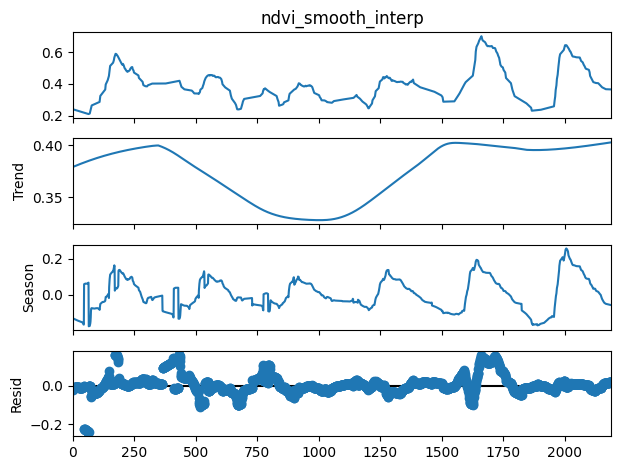

In [20]:
stl.plot()
plt.show()

In [21]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [22]:
sd = seasonal_decompose(df_train['ndvi_smooth_interp'], model="additive", period=12)

In [23]:
sd_df = pd.DataFrame(
    {
        "observed": sd.observed, 
        "trend": sd.trend, 
        "seasonal": sd.seasonal, 
        "resid": sd.resid
    })

In [24]:
sd_df = sd_df.bfill().ffill()

In [25]:
def plot_ts_resid(x):
    x = x[x.notna()] # remove NAs
    fig, axes = plt.subplots(1, 2, figsize = (15, 5))
    fig = sns.lineplot(x=x.index, y=x, ax = axes[0])
    fig = sns.distplot(x, ax = axes[1]);
    return None

In [26]:
import statsmodels.api as sm

def plot_acf_pacf(x, lags=48):
    x = x[x.notna()] # remove NAs
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig = sm.graphics.tsa.plot_acf(x, lags=lags, ax=axes[0])
    fig = sm.graphics.tsa.plot_pacf(x, lags=lags, ax=axes[1]);
    return None

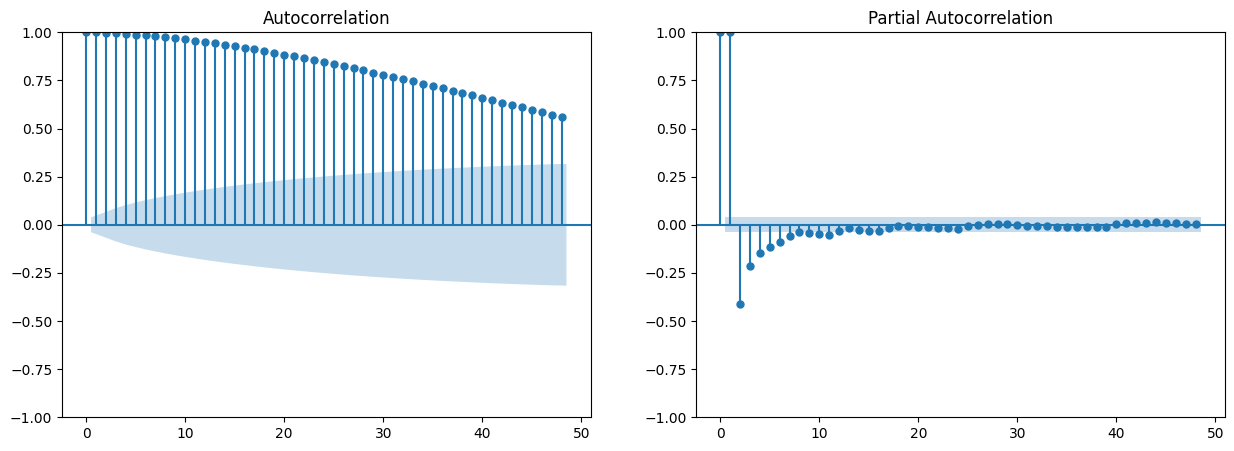

In [27]:
plot_acf_pacf(df['ndvi_smooth_interp'])

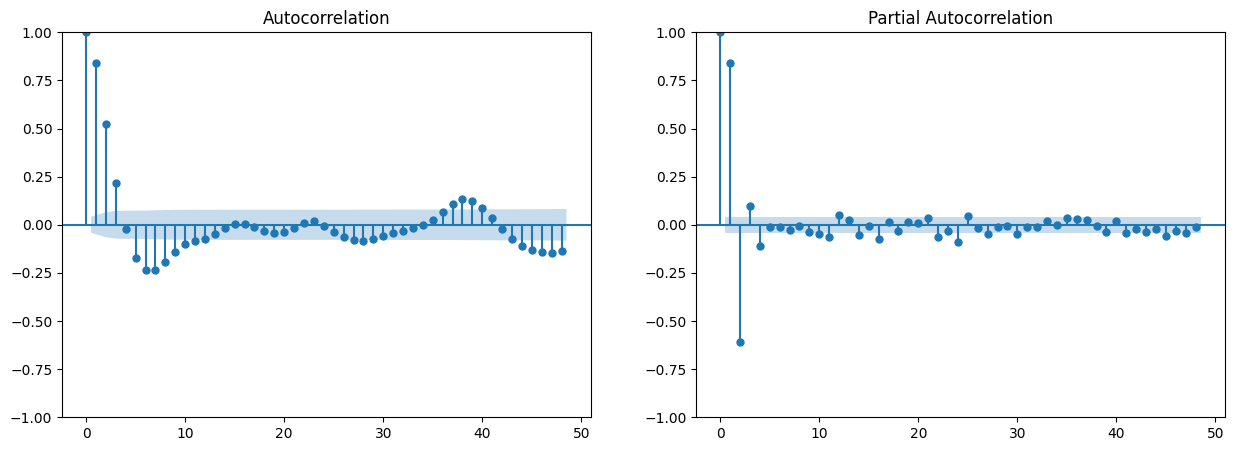

In [28]:
plot_acf_pacf(sd_df["resid"])

In [29]:
from statsmodels.tsa.ar_model import AutoReg

In [30]:
mod = AutoReg(df_train['ndvi_smooth_interp'], lags=30)

In [31]:
res = mod.fit()
print(res.summary())

                            AutoReg Model Results                             
Dep. Variable:     ndvi_smooth_interp   No. Observations:                 2191
Model:                    AutoReg(30)   Log Likelihood               10969.149
Method:               Conditional MLE   S.D. of innovations              0.002
Date:                Sat, 29 Nov 2025   AIC                         -21874.297
Time:                        09:20:34   BIC                         -21692.591
Sample:                            30   HQIC                        -21807.840
                                 2191                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.0006      0.000      4.265      0.000       0.000       0.001
ndvi_smooth_interp.L1      1.9174      0.021     89.227      0.000       1.875       1.960
ndvi

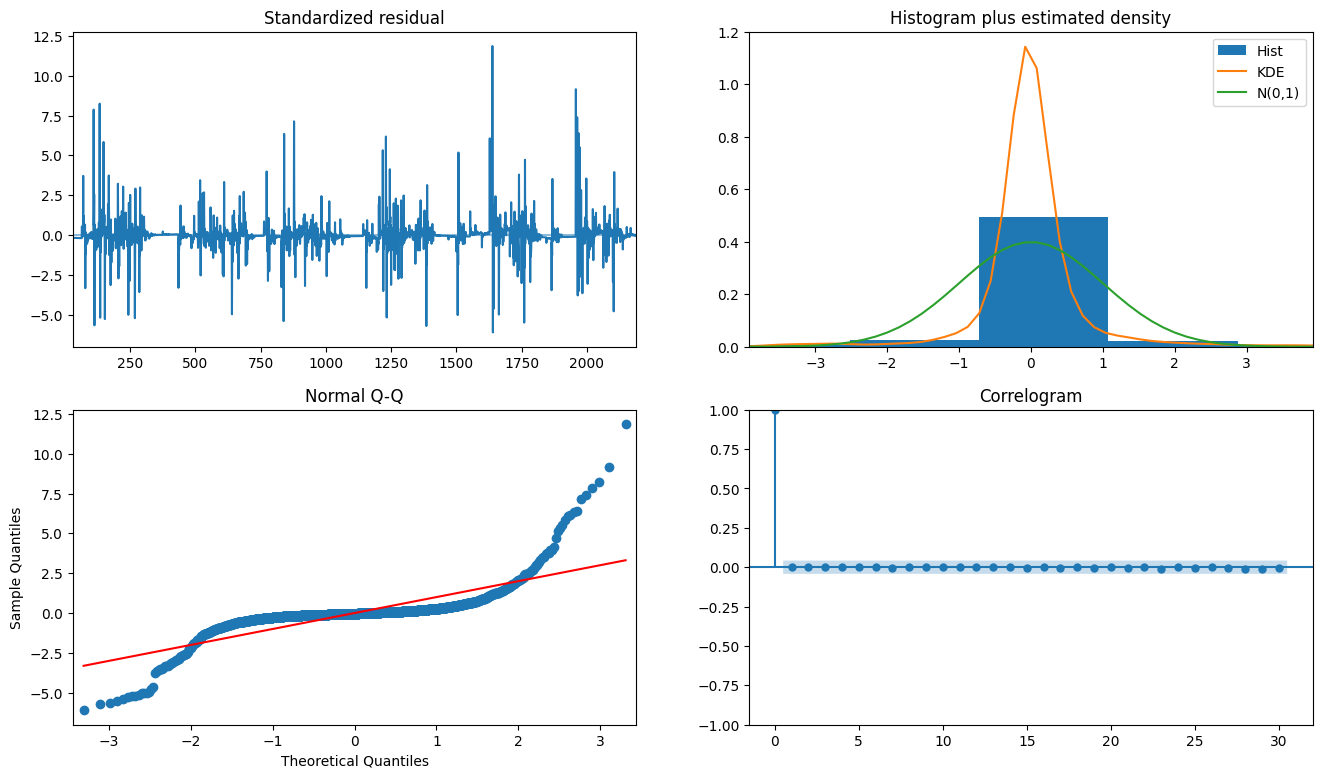

In [32]:
# visulize diagnostic statistics
fig = plt.figure(figsize=(16, 9))
fig = res.plot_diagnostics(fig=fig, lags=30)

In [33]:
df_train

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week
0,0.239840,2018-01-01,0.0000,2.2500,-0.7660,-3.7820,2.2700,0.1100,1,2018,1,1
1,0.239356,2018-01-02,0.0000,0.8120,-1.4050,-3.6220,1.7930,0.1720,2,2018,1,1
2,0.238872,2018-01-03,0.0000,-0.1870,-0.9840,-1.7810,1.2260,0.2950,3,2018,1,1
3,0.238389,2018-01-04,0.0000,2.0680,-0.3580,-2.7850,2.3790,0.1400,4,2018,1,1
4,0.237905,2018-01-05,0.0000,1.0690,-0.6430,-2.3550,1.3650,0.1100,5,2018,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2186,0.365435,2023-12-27,0.0000,4.2250,2.3597,0.4947,0.5395,0.0154,361,2023,12,52
2187,0.365369,2023-12-28,1.7383,5.3677,2.5631,-0.2415,0.6784,0.0072,362,2023,12,52
2188,0.365303,2023-12-29,0.0000,3.7730,2.0917,0.4105,0.4038,0.0326,363,2023,12,52
2189,0.365237,2023-12-30,0.0000,4.3290,2.5446,0.7605,0.2497,0.0007,364,2023,12,52


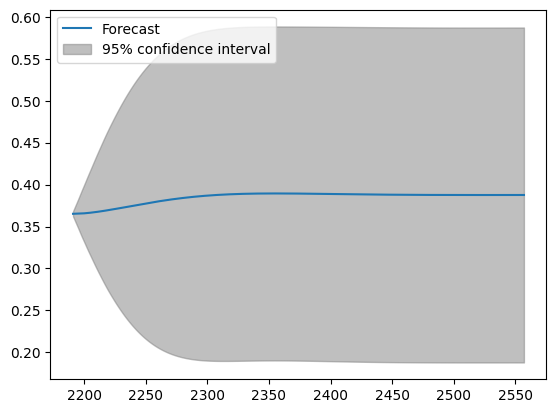

In [34]:
fig = res.plot_predict(start=2191, end=2191 + 366)

In [35]:
y_test_pred = res.predict(start=2191, end=2191 + 366)

In [36]:
from statsmodels.tsa.arima.model import ARIMA

In [37]:
df_train

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week
0,0.239840,2018-01-01,0.0000,2.2500,-0.7660,-3.7820,2.2700,0.1100,1,2018,1,1
1,0.239356,2018-01-02,0.0000,0.8120,-1.4050,-3.6220,1.7930,0.1720,2,2018,1,1
2,0.238872,2018-01-03,0.0000,-0.1870,-0.9840,-1.7810,1.2260,0.2950,3,2018,1,1
3,0.238389,2018-01-04,0.0000,2.0680,-0.3580,-2.7850,2.3790,0.1400,4,2018,1,1
4,0.237905,2018-01-05,0.0000,1.0690,-0.6430,-2.3550,1.3650,0.1100,5,2018,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2186,0.365435,2023-12-27,0.0000,4.2250,2.3597,0.4947,0.5395,0.0154,361,2023,12,52
2187,0.365369,2023-12-28,1.7383,5.3677,2.5631,-0.2415,0.6784,0.0072,362,2023,12,52
2188,0.365303,2023-12-29,0.0000,3.7730,2.0917,0.4105,0.4038,0.0326,363,2023,12,52
2189,0.365237,2023-12-30,0.0000,4.3290,2.5446,0.7605,0.2497,0.0007,364,2023,12,52


In [38]:
mod = ARIMA(df_train.set_index('date')['ndvi_smooth_interp'], order=(1, 0, 1), dates=df['date'])

/home/simonhans/anaconda3/envs/GrapeExpectationsML/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/simonhans/anaconda3/envs/GrapeExpectationsML/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/home/simonhans/anaconda3/envs/GrapeExpectationsML/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [39]:
res = mod.fit()
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:     ndvi_smooth_interp   No. Observations:                 2191
Model:                 ARIMA(1, 0, 1)   Log Likelihood               10111.248
Date:                Sat, 29 Nov 2025   AIC                         -20214.496
Time:                        09:20:36   BIC                         -20191.728
Sample:                    01-01-2018   HQIC                        -20206.175
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3824      0.057      6.688      0.000       0.270       0.494
ar.L1          0.9989      0.001   1264.959      0.000       0.997       1.000
ma.L1          0.9243      0.002    412.328      0.0

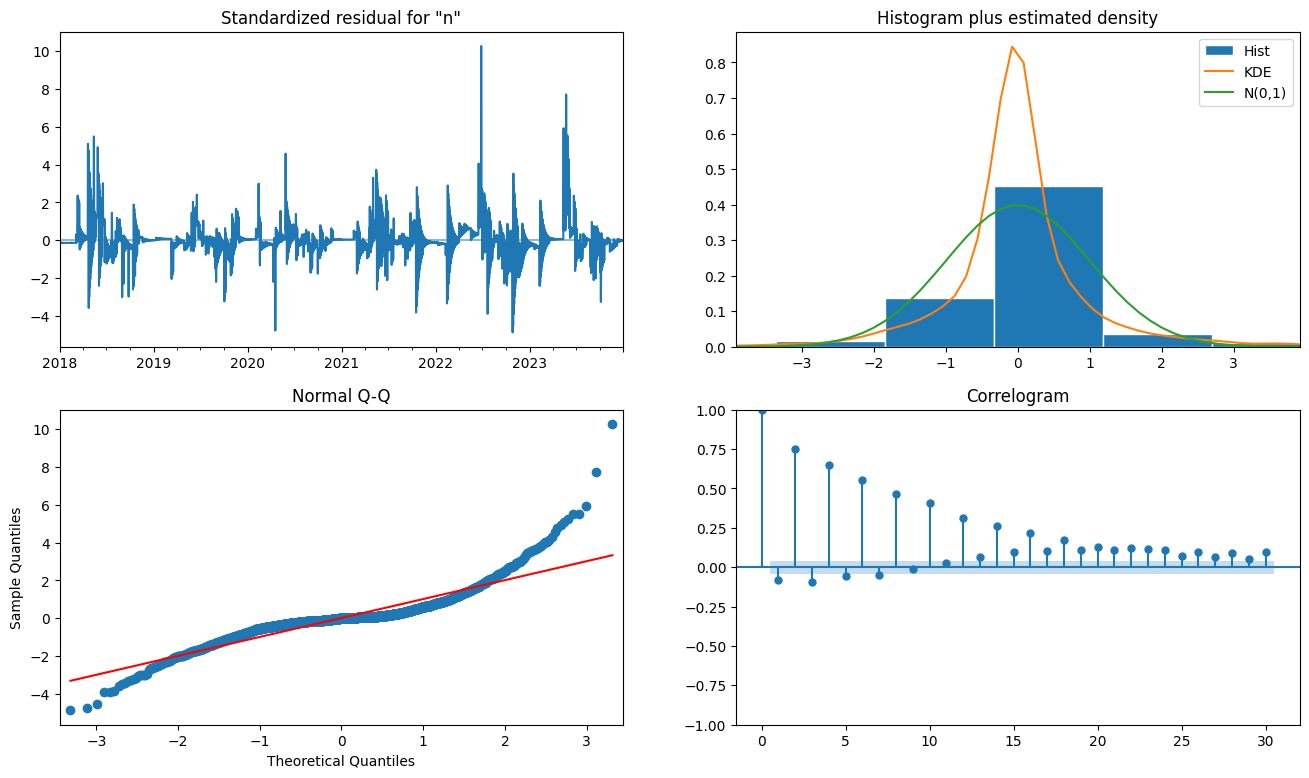

In [40]:
# visulize diagnostic statistics
fig = plt.figure(figsize=(16, 9))
fig = res.plot_diagnostics(fig=fig, lags=30)

In [41]:
y_test_pred = res.predict(start=2191, end=2191 + 365)

In [42]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_true=df_test['ndvi_smooth_interp'], y_pred=y_test_pred)

0.1094926951580216

In [43]:
y_test_pred

2024-01-01    0.365181
2024-01-02    0.365200
2024-01-03    0.365218
2024-01-04    0.365237
2024-01-05    0.365255
                ...   
2024-12-27    0.370725
2024-12-28    0.370737
2024-12-29    0.370750
2024-12-30    0.370762
2024-12-31    0.370775
Freq: D, Name: predicted_mean, Length: 366, dtype: float64

In [44]:
df_train

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week
0,0.239840,2018-01-01,0.0000,2.2500,-0.7660,-3.7820,2.2700,0.1100,1,2018,1,1
1,0.239356,2018-01-02,0.0000,0.8120,-1.4050,-3.6220,1.7930,0.1720,2,2018,1,1
2,0.238872,2018-01-03,0.0000,-0.1870,-0.9840,-1.7810,1.2260,0.2950,3,2018,1,1
3,0.238389,2018-01-04,0.0000,2.0680,-0.3580,-2.7850,2.3790,0.1400,4,2018,1,1
4,0.237905,2018-01-05,0.0000,1.0690,-0.6430,-2.3550,1.3650,0.1100,5,2018,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2186,0.365435,2023-12-27,0.0000,4.2250,2.3597,0.4947,0.5395,0.0154,361,2023,12,52
2187,0.365369,2023-12-28,1.7383,5.3677,2.5631,-0.2415,0.6784,0.0072,362,2023,12,52
2188,0.365303,2023-12-29,0.0000,3.7730,2.0917,0.4105,0.4038,0.0326,363,2023,12,52
2189,0.365237,2023-12-30,0.0000,4.3290,2.5446,0.7605,0.2497,0.0007,364,2023,12,52


In [45]:
df_test

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week
0,0.365105,2024-01-01,0.8332,3.780500,2.66450,1.5488,0.2155,0.0000,1,2024,1,1
1,0.365039,2024-01-02,0.0000,4.306400,3.32640,2.3466,0.7829,0.0834,2,2024,1,1
2,0.364973,2024-01-03,9.8660,3.418500,2.36660,1.3149,0.5331,0.0837,3,2024,1,1
3,0.364907,2024-01-04,1.1649,5.356500,2.79170,0.2271,1.3780,0.0729,4,2024,1,1
4,0.364841,2024-01-05,2.6135,7.704200,4.30870,0.9136,1.9897,0.1409,5,2024,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
361,0.473407,2024-12-27,5.5226,12.897300,8.57640,4.2555,5.3272,0.0464,362,2024,12,52
362,0.473407,2024-12-28,2.7350,9.500899,6.92395,4.3470,1.8989,0.0603,363,2024,12,52
363,0.473407,2024-12-29,6.4769,13.031700,9.00255,4.9734,4.6196,0.0594,364,2024,12,52
364,0.473407,2024-12-30,0.9107,9.572500,6.35390,3.1353,2.6949,0.1705,365,2024,12,1


In [46]:
y_test_pred

2024-01-01    0.365181
2024-01-02    0.365200
2024-01-03    0.365218
2024-01-04    0.365237
2024-01-05    0.365255
                ...   
2024-12-27    0.370725
2024-12-28    0.370737
2024-12-29    0.370750
2024-12-30    0.370762
2024-12-31    0.370775
Freq: D, Name: predicted_mean, Length: 366, dtype: float64

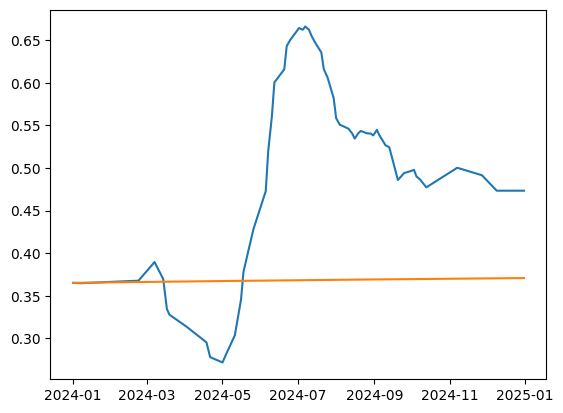

In [47]:
plt.plot(df_test['date'],df_test['ndvi_smooth_interp'])
plt.plot(y_test_pred.index, y_test_pred)

# 4. Phenology Detection: Inflection Points

We detect:
- Budbreak  
- Peak vigor  
- Onset of senescence  
- Dormancy  
Using:
- First derivative of seasonal component  
- Second derivative  
- Peak-finding heuristics  


In [48]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['week'] = df['date'].dt.isocalendar().week

In [49]:
# df = df.sort_values("date").reset_index(drop=True)

# Assuming NDVI is smoothed (e.g., spline, GAM, Savitzky-Golay)
# ndvi = df["ndvi"].values

# 1st derivative
df["d1"] = np.gradient(df['ndvi_smooth_interp'])

# 2nd derivative
df["d2"] = np.gradient(df["d1"])


In [50]:
df

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week,d1,d2
0,0.239840,2018-01-01,0.0000,2.250000,-0.76600,-3.7820,2.2700,0.1100,1,2018,1,1,-0.000484,1.387779e-17
1,0.239356,2018-01-02,0.0000,0.812000,-1.40500,-3.6220,1.7930,0.1720,2,2018,1,1,-0.000484,6.938894e-18
2,0.238872,2018-01-03,0.0000,-0.187000,-0.98400,-1.7810,1.2260,0.2950,3,2018,1,1,-0.000484,-6.938894e-18
3,0.238389,2018-01-04,0.0000,2.068000,-0.35800,-2.7850,2.3790,0.1400,4,2018,1,1,-0.000484,-6.938894e-18
4,0.237905,2018-01-05,0.0000,1.069000,-0.64300,-2.3550,1.3650,0.1100,5,2018,1,1,-0.000484,6.938894e-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,0.473407,2024-12-27,5.5226,12.897300,8.57640,4.2555,5.3272,0.0464,362,2024,12,52,0.000000,0.000000e+00
2553,0.473407,2024-12-28,2.7350,9.500899,6.92395,4.3470,1.8989,0.0603,363,2024,12,52,0.000000,0.000000e+00
2554,0.473407,2024-12-29,6.4769,13.031700,9.00255,4.9734,4.6196,0.0594,364,2024,12,52,0.000000,0.000000e+00
2555,0.473407,2024-12-30,0.9107,9.572500,6.35390,3.1353,2.6949,0.1705,365,2024,12,1,0.000000,0.000000e+00


In [51]:
from scipy.signal import find_peaks

peaks, props = find_peaks(df["d2"], distance=30, prominence=0.0005)
df["peak_flag"] = 0
df.loc[peaks, "peak_flag"] = 1


In [52]:
events = (
    df[df["peak_flag"] == 1]
    .groupby("year")
    .apply(lambda d: d.sort_values("date"))
)


/tmp/ipykernel_17573/1913863542.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d.sort_values("date"))


In [53]:
label_map = {
    0: "budbreak",
    1: "expansion_accel",
    2: "summer_plateau",
    3: "senescence_onset",
    4: "leaf_drop"
}

def label_events(group):
    idxs = group.index.tolist()
    # You may have 4 or 5 events; adapt dynamically:
    n = len(idxs)

    # Rank events by sequence
    ranks = list(range(n))
    group["phenophase"] = [label_map.get(r, f"event_{r}") for r in ranks]
    return group

labeled_events = (
    df[df["peak_flag"] == 1]
      .groupby("year")
      .apply(label_events)
)


/tmp/ipykernel_17573/1096581174.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(label_events)


In [54]:
df

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week,d1,d2,peak_flag
0,0.239840,2018-01-01,0.0000,2.250000,-0.76600,-3.7820,2.2700,0.1100,1,2018,1,1,-0.000484,1.387779e-17,0
1,0.239356,2018-01-02,0.0000,0.812000,-1.40500,-3.6220,1.7930,0.1720,2,2018,1,1,-0.000484,6.938894e-18,0
2,0.238872,2018-01-03,0.0000,-0.187000,-0.98400,-1.7810,1.2260,0.2950,3,2018,1,1,-0.000484,-6.938894e-18,0
3,0.238389,2018-01-04,0.0000,2.068000,-0.35800,-2.7850,2.3790,0.1400,4,2018,1,1,-0.000484,-6.938894e-18,0
4,0.237905,2018-01-05,0.0000,1.069000,-0.64300,-2.3550,1.3650,0.1100,5,2018,1,1,-0.000484,6.938894e-18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,0.473407,2024-12-27,5.5226,12.897300,8.57640,4.2555,5.3272,0.0464,362,2024,12,52,0.000000,0.000000e+00,0
2553,0.473407,2024-12-28,2.7350,9.500899,6.92395,4.3470,1.8989,0.0603,363,2024,12,52,0.000000,0.000000e+00,0
2554,0.473407,2024-12-29,6.4769,13.031700,9.00255,4.9734,4.6196,0.0594,364,2024,12,52,0.000000,0.000000e+00,0
2555,0.473407,2024-12-30,0.9107,9.572500,6.35390,3.1353,2.6949,0.1705,365,2024,12,1,0.000000,0.000000e+00,0


In [55]:
ev = labeled_events

In [56]:
phenophase_series = ev['phenophase'].droplevel(0)

In [57]:
df['phenophase'] = phenophase_series

In [87]:
df.loc[df[
    (df['phenophase'] == 'event_5') |
    (df['phenophase'] == 'event_6') |
    (df['phenophase'] == 'event_7')].index, 'phenophase'] = np.nan

In [88]:
df[~df['phenophase'].isna()]

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week,d1,d2,peak_flag,phenophase
69,0.212601,2018-03-11,0.0000,14.598000,6.112000,-2.373000,11.277000,0.416000,70,2018,3,10,0.003532,0.002881,1,budbreak
132,0.364547,2018-05-13,0.0000,28.650000,18.936001,9.223000,31.273001,0.344000,133,2018,5,19,0.009046,0.007027,1,expansion_accel
167,0.549699,2018-06-17,2.0010,25.127001,19.567001,14.007000,20.052999,2.272000,168,2018,6,24,0.006948,0.001846,1,summer_plateau
202,0.520805,2018-07-22,0.0000,29.721001,20.937000,12.154000,32.793999,2.833000,203,2018,7,29,0.000501,0.002593,1,senescence_onset
232,0.487937,2018-08-21,0.0000,30.981001,23.898001,16.815001,33.422001,6.138000,233,2018,8,34,0.002839,0.001246,1,leaf_drop
442,0.381588,2019-03-19,0.0000,13.194000,6.134000,-0.925000,7.120000,0.030000,78,2019,3,12,-0.003063,0.001749,1,budbreak
517,0.348218,2019-06-02,0.0000,32.821999,23.886900,14.952000,38.117001,1.274000,153,2019,6,22,0.004954,0.002573,1,expansion_accel
557,0.452876,2019-07-12,0.0000,31.069000,24.094999,17.121000,30.406000,3.977000,193,2019,7,28,0.000633,0.001218,1,summer_plateau
609,0.397875,2019-09-02,0.0000,32.311001,24.289900,16.268999,33.744999,2.832000,245,2019,9,36,-0.005186,0.003306,1,senescence_onset
642,0.331919,2019-10-05,0.0000,18.552000,12.960899,7.370000,12.978000,0.850000,278,2019,10,40,-0.006828,0.001706,1,leaf_drop


In [89]:
df['phenophase'][~df['phenophase'].isna()]

69              budbreak
132      expansion_accel
167       summer_plateau
202     senescence_onset
232            leaf_drop
442             budbreak
517      expansion_accel
557       summer_plateau
609     senescence_onset
642            leaf_drop
772             budbreak
839      expansion_accel
877       summer_plateau
917     senescence_onset
949            leaf_drop
1157            budbreak
1229     expansion_accel
1267      summer_plateau
1297    senescence_onset
1354           leaf_drop
1507            budbreak
1552     expansion_accel
1637      summer_plateau
1667    senescence_onset
1709           leaf_drop
1867            budbreak
1957     expansion_accel
1997      summer_plateau
2032    senescence_onset
2067           leaf_drop
2267            budbreak
2302     expansion_accel
2347      summer_plateau
2404    senescence_onset
2454           leaf_drop
Name: phenophase, dtype: object

In [209]:
import matplotlib.pyplot as plt
import numpy as np

cmap = plt.get_cmap("RdYlGn_r")

# sample just the top/bottom 25% on each side to avoid yellow
colors = np.concatenate([
    cmap(np.linspace(0.0, 0.25, 3)),   # dark reds
    cmap(np.linspace(0.75, 1.0, 2))    # dark greens
])
colors = colors[:5]  # pick first 5


In [210]:
colors

array([[0.        , 0.40784314, 0.21568627, 1.        ],
       [0.17793156, 0.63306421, 0.33271819, 1.        ],
       [0.52795079, 0.79715494, 0.40222991, 1.        ],
       [0.97347174, 0.54740484, 0.31810842, 1.        ],
       [0.64705882, 0.        , 0.14901961, 1.        ]])

In [211]:
phases = [i for i in df['phenophase'].unique()[1:]]

In [212]:
phases

['budbreak',
 'expansion_accel',
 'summer_plateau',
 'senescence_onset',
 'leaf_drop']

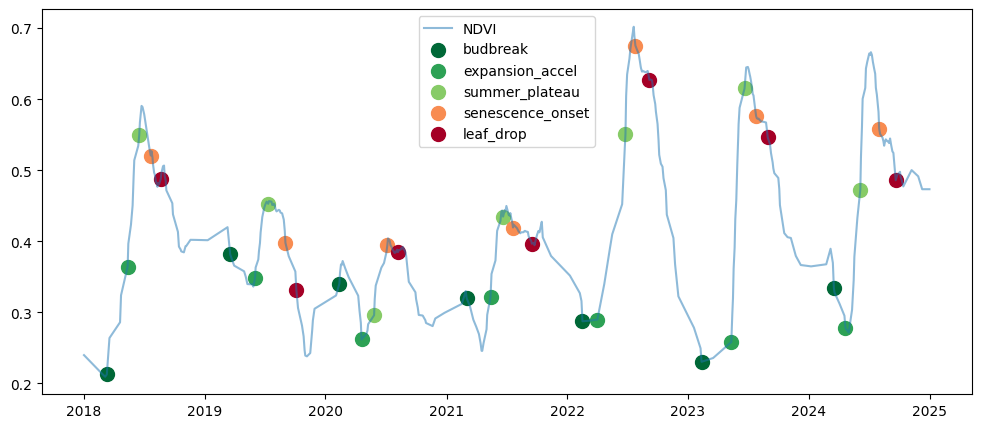

In [213]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["ndvi_smooth_interp"], label="NDVI", alpha = 0.5)


for n, i in enumerate(phases):
    plt.scatter(
        df['date'][df['phenophase'] == i],
        df['ndvi_smooth_interp'][df['phenophase'] == i],
        color = colors[n], 
        label = i,
        s = 100
    )

plt.legend()
# plot phenophase points
# ev = labeled_events

# for _, r in ev.iterrows():
#     ax.text(r["date"], df.loc[r.name, "ndvi_smooth_interp"]+0.005, r["phenophase"], rotation=45)

# ax.legend()
# plt.show()


# 5. Explaining NDVI Components with Weather + Static Features

We analyze relationships between:
- Trend ↔ long-term climate + soil  
- Seasonal amplitude ↔ GDD, early-season VPD, slope/aspect  
- Residuals ↔ heatwaves, rainfall pulses, irrigation events  

Models (simple here; can be upgraded):
- Linear regression (explanatory only)
- Correlations
- Grouped year-level statistics


In [201]:
# Example: compute seasonal amplitude per year
amp = df.groupby("year")["ndvi_smooth_interp"].agg(lambda x: x.max() - x.min())
# gdd = df.groupby("year")["GDD"].sum()  # if GDD exists

# Example correlation
# corr = amp.corr(gdd)
# corr


# 6. Time-Series Modeling with Exogenous Variables (SARIMAX)

Goal: Predict NDVI (or seasonal component) using weather + static features.

We will:
- Fit SARIMAX using exogenous variables  
- Train on first 8 years  
- Validate on year 9  


In [62]:
df

,ndvi_smooth_interp,date,ppt,tmax,tmean,tmin,vpdmax,vpdmin,doy,year,month,week,d1,d2,peak_flag,phenophase
0,0.239840,2018-01-01,0.0000,2.250000,-0.76600,-3.7820,2.2700,0.1100,1,2018,1,1,-0.000484,1.387779e-17,0,NaN
1,0.239356,2018-01-02,0.0000,0.812000,-1.40500,-3.6220,1.7930,0.1720,2,2018,1,1,-0.000484,6.938894e-18,0,NaN
2,0.238872,2018-01-03,0.0000,-0.187000,-0.98400,-1.7810,1.2260,0.2950,3,2018,1,1,-0.000484,-6.938894e-18,0,NaN
3,0.238389,2018-01-04,0.0000,2.068000,-0.35800,-2.7850,2.3790,0.1400,4,2018,1,1,-0.000484,-6.938894e-18,0,NaN
4,0.237905,2018-01-05,0.0000,1.069000,-0.64300,-2.3550,1.3650,0.1100,5,2018,1,1,-0.000484,6.938894e-18,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2552,0.473407,2024-12-27,5.5226,12.897300,8.57640,4.2555,5.3272,0.0464,362,2024,12,52,0.000000,0.000000e+00,0,NaN
2553,0.473407,2024-12-28,2.7350,9.500899,6.92395,4.3470,1.8989,0.0603,363,2024,12,52,0.000000,0.000000e+00,0,NaN
2554,0.473407,2024-12-29,6.4769,13.031700,9.00255,4.9734,4.6196,0.0594,364,2024,12,52,0.000000,0.000000e+00,0,NaN
2555,0.473407,2024-12-30,0.9107,9.572500,6.35390,3.1353,2.6949,0.1705,365,2024,12,1,0.000000,0.000000e+00,0,NaN


In [63]:
weather_cols = ['ppt', 'tmax', 'tmean', 'tmin', 'vpdmax', 'vpdmin']

In [64]:
# # Select target + exogenous variables
# y = df_train["ndvi_smooth_interp"]
# X = df_train[weather_cols]  # placeholders

# # Train-test split by date
# # train = df[df["year"] < df["year"].max()]
# # test = df[df["year"] == df["year"].max()]

# # Fit SARIMAX (parameters placeholder)
# model = SARIMAX(df_train["ndvi_smooth_interp"], exog=df_train[X.columns],
#                 order=(1,1,1), seasonal_order=(1,1,1,365))
# res = model.fit(disp=False)

In [65]:
# # Forecast
# forecast = res.predict(start=df_train.index[-1], end=df_train.index[-1] + 365,
#                        exog=df_test[X.columns])

# 7. Predicting the Next Year's Phenology Curve

We predict a full year ahead using:
- Fitted model  
- Weather normals or forecast data  


In [66]:
# Placeholder for future weather normals
# X_future = test[X.columns].copy()

# Forecast 1-year NDVI
# future_pred = res.predict(start=len(df), end=len(df)+364, exog=X_future)

# Plot
# plt.figure(figsize=(12,4))
# plt.plot(df["date"], df["ndvi"], alpha=0.5, label="History")
# plt.plot(pd.date_range(df["date"].iloc[-1]+pd.Timedelta(days=1), periods=365),
#          future_pred, label="Forecast")
# plt.legend()
# plt.show()


# 8. Scaling Blueprint for All Vineyard Plots

To extend analysis:
- Wrap STL in a function  
- Wrap phenology detection in a function  
- Wrap SARIMAX fitting + forecasting in a function  
- Apply per-plot (loop or groupby)  
- Produce plot-level output tables:
  - Phenology dates  
  - Seasonal amplitude  
  - Trend slope  
  - Irrigation responsiveness  


In [67]:
# Pseudocode structure
# def analyze_plot(df_plot, df_weather, df_static):
#     ...
#     return results_dict


# 9. Conclusions & Viticultural Recommendations

Summaries may include:
- How NDVI trend relates to soil water capacity  
- How seasonal shape changes with climate variability  
- Which weather indicators predict budbreak and senescence  
- How responsive NDVI is to irrigation events  
- Expected phenology dates for the upcoming year  
